In [99]:
%pip install google-cloud-bigquery
%pip install -q db-dtypes

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [100]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.cloud import bigquery
import warnings
warnings.filterwarnings('ignore') 

In [101]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" -gu "mt076" -iv -v

Author: Matheus dos Anjos

Github username: mt076

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.7.0

matplotlib: 3.10.6
pandas    : 2.3.3
plotly    : 6.3.0
seaborn   : 0.13.2



In [102]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "cap04-486320-a6023474858c.json"

In [103]:
client = bigquery.Client()

In [104]:
# Consulta SQL

query = """
SELECT 
      p.Nome AS Nome_Produto,
      f.Valor,
      f.Quantidade,
      c.Nome AS Nome_Canal
    FROM `cap04-486320.Projeto2.fato_venda` AS f
    JOIN `cap04-486320.Projeto2.dim_produto` AS p ON f.Produto_ID = p.Produto_ID
    JOIN `cap04-486320.Projeto2.dim_canal` AS c ON f.Canal_ID = c.Canal_ID
    WHERE p.Nome = 'Produto A'
    LIMIT 100"""

In [105]:
df = client.query(query).to_dataframe()

In [106]:
df.head(3)

,Nome_Produto,Valor,Quantidade,Nome_Canal
0,Produto A,268.22,4,Quiosque
1,Produto A,883.81,12,Loja Online


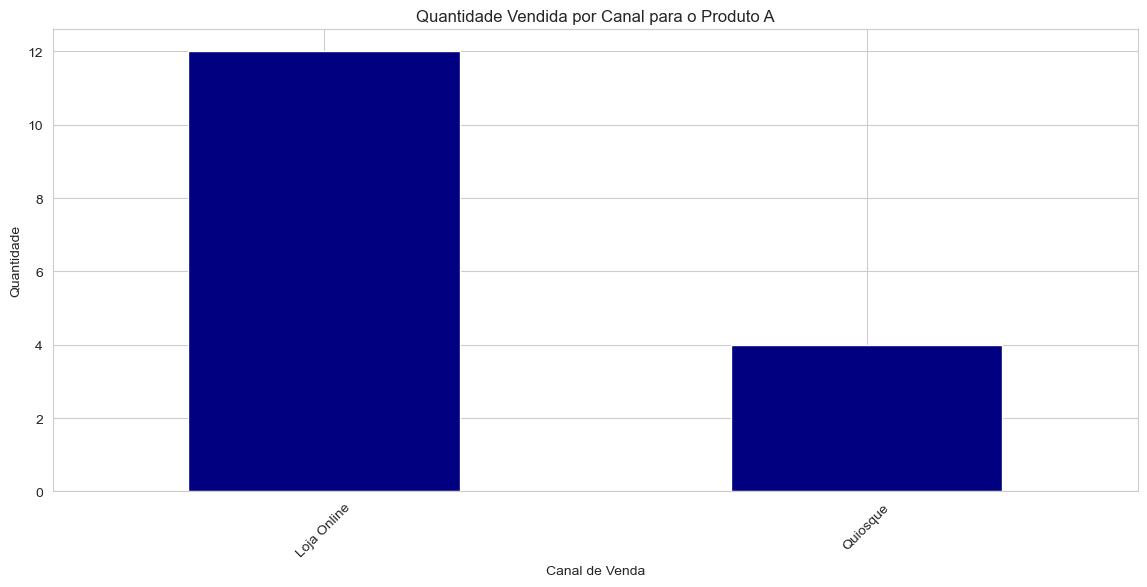

In [107]:
plt.figure(figsize = (14, 6))
df.groupby("Nome_Canal")["Quantidade"].sum().plot(kind = 'bar', color = 'navy')
plt.title('Quantidade Vendida por Canal para o Produto A')
plt.ylabel('Quantidade')
plt.xlabel('Canal de Venda')
plt.xticks(rotation = 45)
plt.show()

In [108]:
query = """ 
        WITH Total_Cliente_Vendas AS (
        SELECT
          cl.Nome AS Nome_Cliente,
          d.Ano,
          SUM(f.Valor) AS Total_Valor_Vendas,
          ROW_NUMBER() OVER (PARTITION BY d.Ano ORDER BY SUM(f.Valor) DESC) AS Rank_Vendas
          FROM `cap04-486320.Projeto2.fato_venda` AS f
          JOIN `cap04-486320.Projeto2.dim_cliente` AS cl ON f.Cliente_ID = cl.Cliente_ID
          JOIN `cap04-486320.Projeto2.dim_data` AS d ON f.Data_ID = d.Data_ID
          GROUP BY Nome_Cliente, d.Ano
        )
        SELECT Nome_Cliente, Ano, Total_Valor_Vendas
        FROM Total_Cliente_Vendas
        WHERE Rank_Vendas = 1"""

In [109]:
df2 = client.query(query).to_dataframe()

In [110]:
 df2.head(3)

,Nome_Cliente,Ano,Total_Valor_Vendas
0,João Silva,2020,268.22
1,João Silva,2021,2372.14
2,Maria Oliveira,2022,1410.43


In [111]:
query = """
SELECT p.Nome AS Produto, d.Mes, d.Ano, SUM(f.Valor) AS Total_Vendas
FROM `cap04-486320.Projeto2.fato_venda` AS f
JOIN `cap04-486320.Projeto2.dim_produto` AS p ON f.Produto_ID = p.Produto_ID
JOIN `cap04-486320.Projeto2.dim_data` AS d ON f.Data_ID = d.Data_ID
GROUP BY p.Nome, d.Mes, d.Ano
ORDER BY d.Ano, d.Mes
"""

In [112]:
df_vendas_produto = client.query(query).to_dataframe()

In [113]:
df_vendas_produto['Data'] = pd.to_datetime(df_vendas_produto['Ano'].astype(str) + '-' + df_vendas_produto['Mes'].astype(str) + '-01')

In [114]:
df_vendas_produto.head(3)

,Produto,Mes,Ano,Total_Vendas,Data
0,Produto A,4,2020,268.22,2020-04-01
1,Produto F,7,2020,216.98,2020-07-01
2,Produto C,1,2021,737.86,2021-01-01


In [115]:
top_n = 5
top_produtos = df_vendas_produto.groupby('Produto')['Total_Vendas'].sum().nlargest(top_n).index
df_filtered = df_vendas_produto[df_vendas_produto['Produto'].isin(top_produtos)]

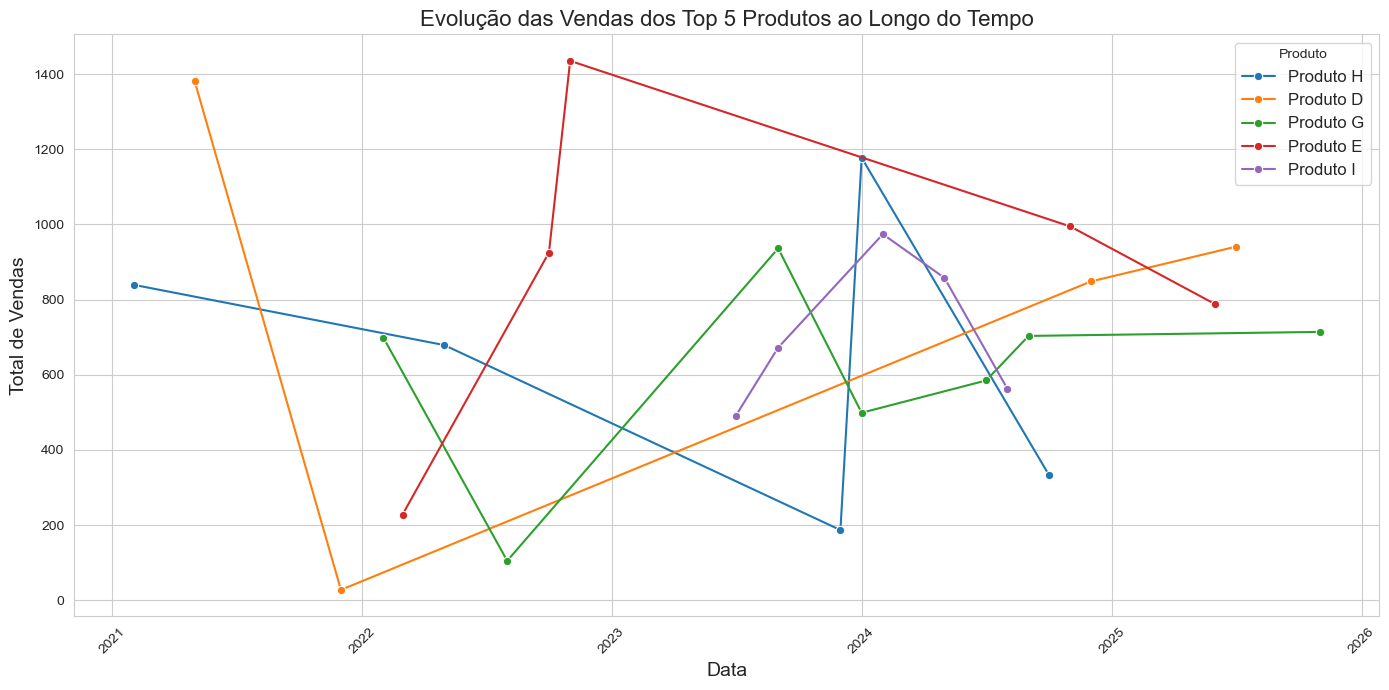

In [116]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))
sns.lineplot(data = df_filtered, x='Data', y='Total_Vendas', hue='Produto', marker='o')
plt.title('Evolução das Vendas dos Top 5 Produtos ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=14)
plt.ylabel('Total de Vendas', fontsize=14)
plt.legend(title='Produto', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [117]:
fig = px.line(df_filtered,
              x = 'Data',
              y = 'Total_Vendas',
              color = 'Produto',
              title = 'Total de Vendas por Produto ao Longo do Tempo',
              labels = {'Total_Vendas': 'Valor das Vendas (R$)', 'Data': 'Data'})

fig.update_layout(xaxis_title='Data',
                  yaxis_title='Valor das Vendas (R$)',
                  legend_title='Produto',
                  xaxis=dict(tickformat='%Y-%m', tickangle=45))

fig.show()

<Figure size 1400x700 with 0 Axes>

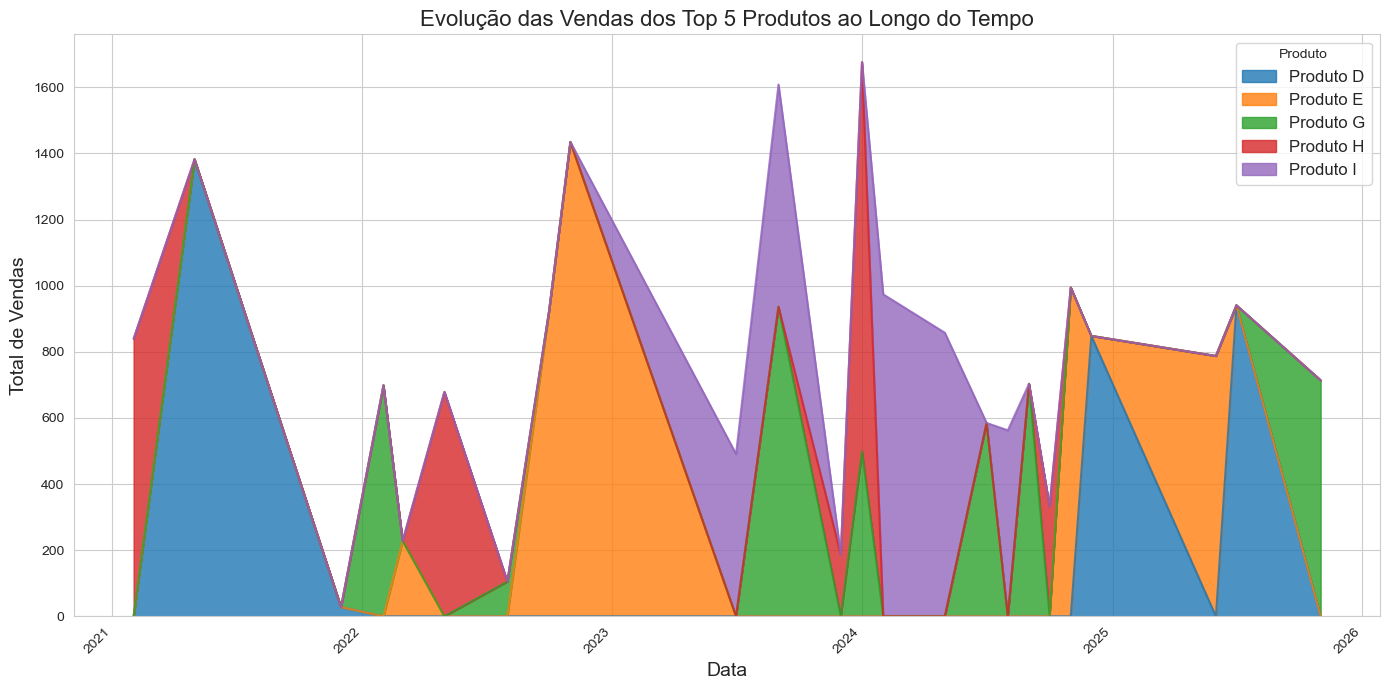

In [118]:
df_pivot = df_filtered.pivot(index='Data', columns='Produto', values='Total_Vendas').fillna(0)
plt.figure(figsize=(14, 7))
df_pivot.plot(kind='area', stacked=True, figsize=(14, 7), alpha=0.8)
plt.title('Evolução das Vendas dos Top 5 Produtos ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=14)
plt.ylabel('Total de Vendas', fontsize=14)
plt.legend(title='Produto', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

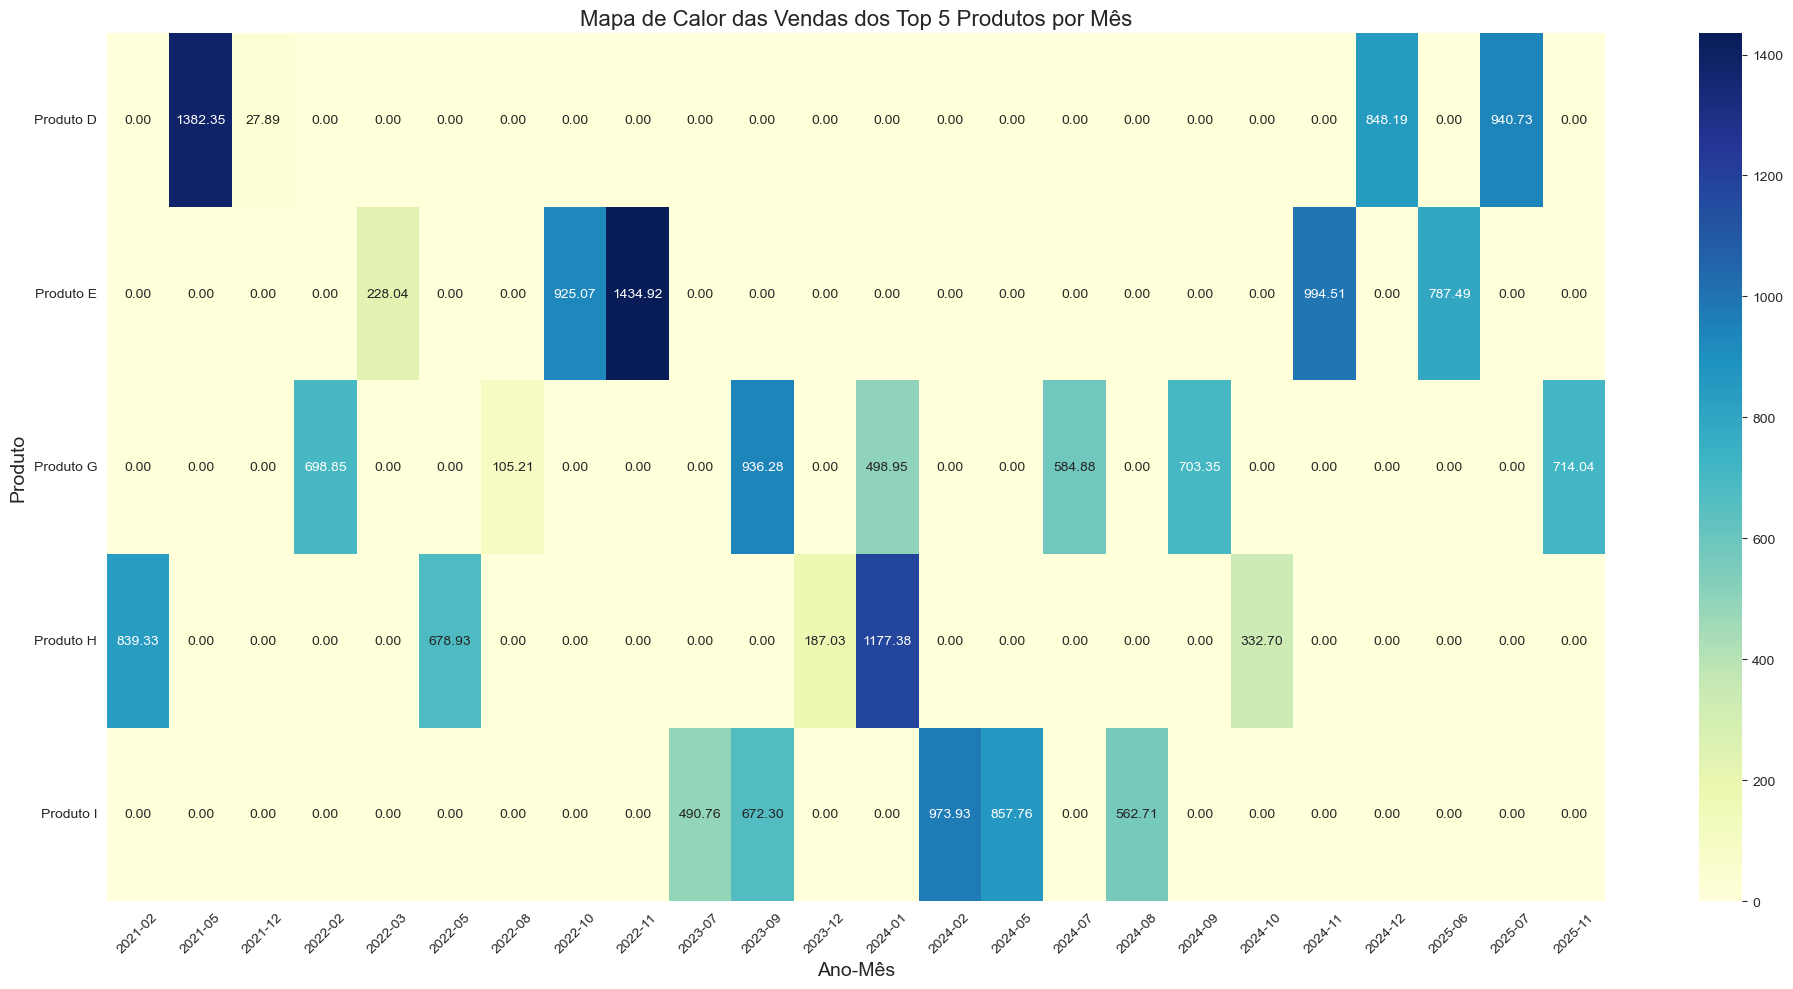

In [119]:
df_filtered['Ano_Mes'] = df_filtered['Data'].dt.to_period('M').astype(str)
heatmap_data = df_filtered.pivot_table(index = 'Produto',
                                       columns = 'Ano_Mes',
                                       values = 'Total_Vendas',
                                       fill_value = 0)
plt.figure(figsize = (20, 10))
sns.heatmap(heatmap_data, annot = True, fmt = '.2f', cmap = 'YlGnBu')
plt.title('Mapa de Calor das Vendas dos Top 5 Produtos por Mês', fontsize=16)
plt.xlabel('Ano-Mês', fontsize=14)
plt.ylabel('Produto', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

In [120]:
query = """
SELECT cl.Nome AS Cliente, COUNT(f.Produto_ID) AS Numero_Compras, AVG(f.Valor) AS Ticket_Medio
FROM `cap04-486320.Projeto2.fato_venda` f
JOIN `cap04-486320.Projeto2.dim_cliente` cl ON f.Cliente_ID = cl.Cliente_ID
GROUP BY cl.Nome
ORDER BY Numero_Compras DESC
"""

In [121]:
df_cliente_frequencia = client.query(query).to_dataframe()

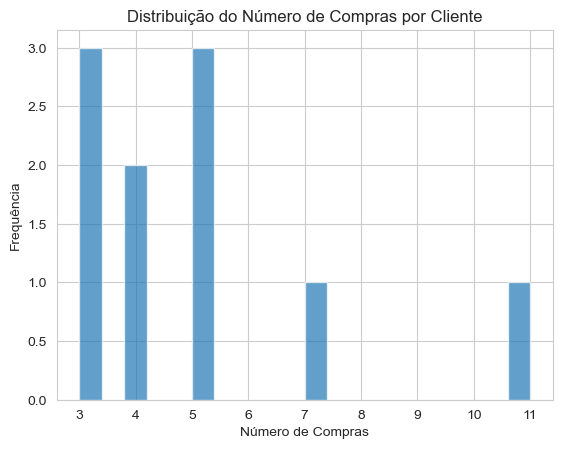

In [122]:
df_cliente_frequencia['Numero_Compras'].plot(kind = 'hist', bins = 20, alpha = 0.7)
plt.title('Distribuição do Número de Compras por Cliente')
plt.xlabel('Número de Compras')
plt.ylabel('Frequência')
plt.show()

In [125]:
query = """
SELECT cl.Cidade, cl.Estado, SUM(f.Valor) AS Total_Vendas
FROM `cap04-486320.Projeto2.fato_venda` f
JOIN `cap04-486320.Projeto2.dim_cliente` cl ON f.Cliente_ID = cl.Cliente_ID
GROUP BY cl.Cidade, cl.Estado
ORDER BY Total_Vendas DESC
LIMIT 10
"""

In [126]:
df_vendas_regiao = client.query(query).to_dataframe()

<Figure size 1400x600 with 0 Axes>

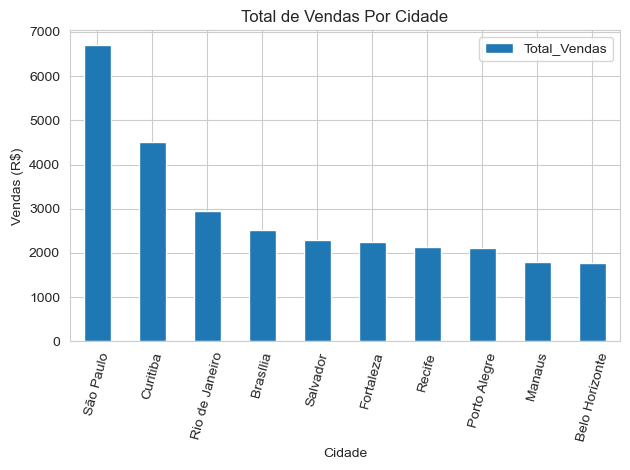

In [127]:
plt.figure(figsize = (14, 6))  

df_vendas_regiao.plot(kind = 'bar', x = 'Cidade', y = 'Total_Vendas')
plt.title('Total de Vendas Por Cidade')
plt.ylabel('Vendas (R$)')
plt.xlabel('Cidade')
plt.xticks(rotation = 75)
plt.tight_layout()
plt.show()